# 모델 프루닝(Model Pruning) 단계별 실습 가이드

## 목차
1. [모델 프루닝이란?](#1-모델-프루닝이란)
2. [프루닝의 장점과 단점](#2-프루닝의-장점과-단점)
3. [프루닝의 종류](#3-프루닝의-종류)
4. [실습 환경 설정](#4-실습-환경-설정)
5. [단계별 실습](#5-단계별-실습)
6. [고급 프루닝 기법](#6-고급-프루닝-기법)
7. [성능 비교 및 분석](#7-성능-비교-및-분석)
8. [Best Practices](#8-best-practices)

---

## 1. 모델 프루닝이란?

모델 프루닝은 신경망에서 중요도가 낮은 연결(가중치)이나 뉴런을 제거하여 모델을 압축하는 기술입니다. 이는 생물학적 시냅스 가지치기에서 영감을 받은 방법입니다.

### 프루닝의 기본 원리
```
원본 네트워크 → 중요도 평가 → 가지치기 → 압축된 네트워크
```

### 핵심 개념
- **희소성(Sparsity)**: 0이 아닌 파라미터의 비율
- **중요도(Importance)**: 파라미터가 모델 성능에 미치는 영향
- **마스크(Mask)**: 어떤 파라미터를 제거할지 결정하는 이진 마스크

## 2. 프루닝의 장점과 단점

### 장점
- **모델 크기 감소**: 50-90% 이상 압축 가능
- **추론 속도 향상**: 특히 구조적 프루닝에서 효과적
- **메모리 사용량 감소**: 엣지 디바이스 배포에 유리
- **정규화 효과**: 과적합 감소 가능

### 단점
- **정확도 손실**: 과도한 프루닝 시 성능 저하
- **재학습 필요**: Fine-tuning 과정 필수
- **하드웨어 의존성**: 비구조적 프루닝은 특수 하드웨어 필요
- **구현 복잡도**: 최적 프루닝 전략 찾기 어려움

## 3. 프루닝의 종류

### 3.1 비구조적 프루닝 (Unstructured Pruning)
- **개별 가중치 제거**: 임의의 위치의 가중치를 0으로 만듦
- **높은 압축률**: 90% 이상 가능
- **특수 하드웨어 필요**: 희소 행렬 연산 지원 필요

### 3.2 구조적 프루닝 (Structured Pruning)
- **채널/필터 단위 제거**: 전체 뉴런이나 채널 제거
- **일반 하드웨어 호환**: 표준 연산으로 처리 가능
- **낮은 압축률**: 보통 50-70%

### 3.3 프루닝 기준
- **Magnitude-based**: 가중치 크기 기반
- **Gradient-based**: 그래디언트 정보 활용
- **Taylor expansion**: 손실 함수의 테일러 급수 활용
- **Lottery Ticket Hypothesis**: 초기화 값으로 재학습

## 4. 실습 환경 설정

In [1]:
# 필요한 라이브러리 설치
!pip install torch torchvision matplotlib numpy pandas seaborn

# 라이브러리 임포트
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from collections import OrderedDict
import copy
import time

## 5. 단계별 실습

### Step 1: 모델 정의

In [2]:
class PrunableCNN(nn.Module):
    """프루닝 실습을 위한 CNN 모델"""
    def __init__(self, num_classes=10):
        super(PrunableCNN, self).__init__()

        # Convolutional layers
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        # Fully connected layers
        self.classifier = nn.Sequential(
            nn.Linear(128 * 8 * 8, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

### Step 2: 프루닝 유틸리티 함수

In [3]:
def calculate_sparsity(model):
    """모델의 희소성 계산"""
    zeros = 0
    total = 0

    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            if hasattr(module, 'weight_mask'):
                zeros += (module.weight_mask == 0).sum().item()
                total += module.weight_mask.numel()
            else:
                zeros += (module.weight == 0).sum().item()
                total += module.weight.numel()

    sparsity = zeros / total if total > 0 else 0
    return sparsity * 100

def count_parameters(model):
    """모델의 파라미터 수 계산"""
    total_params = sum(p.numel() for p in model.parameters())
    nonzero_params = sum((p != 0).sum().item() for p in model.parameters())
    return total_params, nonzero_params

def print_model_size(model):
    """모델 크기 정보 출력"""
    total, nonzero = count_parameters(model)
    sparsity = calculate_sparsity(model)

    print(f"총 파라미터: {total:,}")
    print(f"0이 아닌 파라미터: {nonzero:,}")
    print(f"희소성: {sparsity:.2f}%")
    print(f"압축률: {total/nonzero:.2f}x")

### Step 3: 기본 프루닝 (Magnitude-based)

In [4]:
def magnitude_pruning(model, pruning_rate=0.2):
    """크기 기반 비구조적 프루닝"""
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            prune.l1_unstructured(module, name='weight', amount=pruning_rate)
        elif isinstance(module, nn.Linear):
            prune.l1_unstructured(module, name='weight', amount=pruning_rate)

    return model

def remove_pruning(model):
    """프루닝 마스크를 영구적으로 적용"""
    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            if hasattr(module, 'weight_mask'):
                prune.remove(module, 'weight')
    return model

### Step 4: 구조적 프루닝 (채널/필터 프루닝)

In [5]:
def structured_pruning(model, pruning_rate=0.2):
    """구조적 프루닝 - 채널 단위"""
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            # L2 norm 기준으로 채널 프루닝
            prune.ln_structured(module, name='weight', amount=pruning_rate,
                              n=2, dim=0)  # dim=0은 출력 채널

    return model

def get_channel_importance(conv_layer):
    """채널별 중요도 계산"""
    weights = conv_layer.weight.data
    # 각 출력 채널의 L2 norm 계산
    importance = torch.norm(weights.view(weights.size(0), -1), p=2, dim=1)
    return importance

### Step 5: 반복적 프루닝 (Iterative Pruning)

In [ ]:
def iterative_pruning(model, train_loader, test_loader,
                     target_sparsity=0.9, num_iterations=10):
    """반복적 프루닝 with fine-tuning"""

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    # 프루닝 스케줄 생성
    sparsities = np.linspace(0, target_sparsity, num_iterations)

    results = []

    for i, sparsity in enumerate(sparsities):
        print(f"\n반복 {i+1}/{num_iterations}, 목표 희소성: {sparsity*100:.1f}%")

        # 프루닝 적용
        if i > 0:  # 첫 번째 반복은 프루닝 없음
            pruning_rate = (sparsity - sparsities[i-1]) / (1 - sparsities[i-1])
            model = magnitude_pruning(model, pruning_rate)

        # Fine-tuning
        model = train_model(model, train_loader, epochs=5, device=device)

        # 평가
        accuracy = evaluate_model(model, test_loader, device)
        current_sparsity = calculate_sparsity(model)

        results.append({
            'iteration': i+1,
            'target_sparsity': sparsity * 100,
            'actual_sparsity': current_sparsity,
            'accuracy': accuracy
        })

        print(f"실제 희소성: {current_sparsity:.2f}%, 정확도: {accuracy:.2f}%")

    return model, results

### Step 6: Lottery Ticket Hypothesis

In [6]:
class LotteryTicketPruning:
    """Lottery Ticket Hypothesis 구현"""

    def __init__(self, model, pruning_rate=0.2, rewind_epochs=0):
        self.original_model = copy.deepcopy(model)
        self.pruning_rate = pruning_rate
        self.rewind_epochs = rewind_epochs
        self.initial_state = None
        self.masks = {}

    def save_initial_weights(self):
        """초기 가중치 저장"""
        self.initial_state = copy.deepcopy(self.original_model.state_dict())

    def create_mask(self, model):
        """현재 모델 기반으로 마스크 생성"""
        self.masks = {}

        for name, module in model.named_modules():
            if isinstance(module, (nn.Conv2d, nn.Linear)):
                # 가중치 크기 기준으로 마스크 생성
                weight = module.weight.data.abs()
                threshold = torch.quantile(weight.flatten(), self.pruning_rate)
                mask = weight > threshold
                self.masks[name + '.weight'] = mask

    def apply_mask(self, model):
        """마스크를 모델에 적용"""
        for name, module in model.named_modules():
            if isinstance(module, (nn.Conv2d, nn.Linear)):
                key = name + '.weight'
                if key in self.masks:
                    module.weight.data *= self.masks[key]

    def find_winning_ticket(self, train_loader, test_loader,
                          iterations=3, epochs_per_iteration=10):
        """우승 복권 찾기"""
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        # 초기 가중치 저장
        self.save_initial_weights()

        results = []

        for iteration in range(iterations):
            print(f"\n=== Lottery Ticket 반복 {iteration+1}/{iterations} ===")

            # 모델 초기화
            model = copy.deepcopy(self.original_model)
            model.load_state_dict(self.initial_state)
            model = model.to(device)

            # 이전 마스크가 있으면 적용
            if self.masks:
                self.apply_mask(model)

            # 학습
            model = train_model(model, train_loader, epochs=epochs_per_iteration, device=device)

            # 새로운 마스크 생성
            self.create_mask(model)

            # 초기 가중치로 되돌리고 마스크 적용
            model.load_state_dict(self.initial_state)
            self.apply_mask(model)

            # 재학습
            model = train_model(model, train_loader, epochs=epochs_per_iteration, device=device)

            # 평가
            accuracy = evaluate_model(model, test_loader, device)
            sparsity = calculate_sparsity(model)

            results.append({
                'iteration': iteration + 1,
                'sparsity': sparsity,
                'accuracy': accuracy
            })

            print(f"희소성: {sparsity:.2f}%, 정확도: {accuracy:.2f}%")

            # 다음 반복을 위해 pruning rate 증가
            self.pruning_rate += 0.1

        return model, results

### Step 7: 프루닝 시각화

In [7]:
def visualize_weight_distribution(model, layer_name=None):
    """가중치 분포 시각화"""
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.ravel()

    layer_idx = 0
    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            if layer_name and name != layer_name:
                continue
            if layer_idx >= 4:
                break

            weights = module.weight.data.cpu().numpy().flatten()

            # 히스토그램
            axes[layer_idx].hist(weights, bins=50, alpha=0.7, color='blue', edgecolor='black')
            axes[layer_idx].axvline(x=0, color='red', linestyle='--', alpha=0.5)
            axes[layer_idx].set_title(f'{name} Weight Distribution')
            axes[layer_idx].set_xlabel('Weight Value')
            axes[layer_idx].set_ylabel('Frequency')

            # 통계 정보 추가
            zeros = (weights == 0).sum()
            total = len(weights)
            sparsity = zeros / total * 100

            stats_text = f'Sparsity: {sparsity:.1f}%\nMean: {weights.mean():.4f}\nStd: {weights.std():.4f}'
            axes[layer_idx].text(0.7, 0.9, stats_text, transform=axes[layer_idx].transAxes,
                                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

            layer_idx += 1

    plt.tight_layout()
    plt.savefig('weight_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

def visualize_pruning_mask(model, layer_name=None):
    """프루닝 마스크 시각화"""
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d) and (not layer_name or name == layer_name):
            if hasattr(module, 'weight_mask'):
                mask = module.weight_mask.data.cpu()

                # 첫 번째 출력 채널의 마스크 시각화
                if len(mask.shape) == 4:  # Conv2d
                    plt.figure(figsize=(10, 8))

                    # 여러 입력 채널 표시
                    num_channels = min(16, mask.shape[1])
                    fig, axes = plt.subplots(4, 4, figsize=(12, 12))
                    axes = axes.ravel()

                    for i in range(num_channels):
                        im = axes[i].imshow(mask[0, i].numpy(), cmap='binary', vmin=0, vmax=1)
                        axes[i].set_title(f'Channel {i}')
                        axes[i].axis('off')

                    plt.suptitle(f'Pruning Mask for {name} (First Output Channel)')
                    plt.tight_layout()
                    plt.savefig(f'pruning_mask_{name}.png', dpi=300, bbox_inches='tight')
                    plt.show()
                    break

def plot_pruning_results(results):
    """프루닝 결과 시각화"""
    df = pd.DataFrame(results)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # 희소성 vs 정확도
    ax1.plot(df['actual_sparsity'], df['accuracy'], 'b-o', linewidth=2, markersize=8)
    ax1.set_xlabel('Sparsity (%)')
    ax1.set_ylabel('Accuracy (%)')
    ax1.set_title('Accuracy vs Sparsity Trade-off')
    ax1.grid(True, alpha=0.3)

    # 반복 횟수에 따른 변화
    ax2.plot(df['iteration'], df['actual_sparsity'], 'g-s', label='Sparsity', linewidth=2, markersize=8)
    ax2.set_xlabel('Iteration')
    ax2.set_ylabel('Sparsity (%)', color='g')
    ax2.tick_params(axis='y', labelcolor='g')

    ax2_twin = ax2.twinx()
    ax2_twin.plot(df['iteration'], df['accuracy'], 'r-o', label='Accuracy', linewidth=2, markersize=8)
    ax2_twin.set_ylabel('Accuracy (%)', color='r')
    ax2_twin.tick_params(axis='y', labelcolor='r')

    ax2.set_title('Pruning Progress')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('pruning_results.png', dpi=300, bbox_inches='tight')
    plt.show()

In [8]:
def load_cifar10(batch_size=128):
    """CIFAR-10 데이터셋 로드"""
    print("Loading CIFAR-10 dataset...")

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
    ])

    trainset = torchvision.datasets.CIFAR10(
        root='./data', train=True, download=True, transform=transform
    )
    trainloader = torch.utils.data.DataLoader(
        trainset, batch_size=batch_size, shuffle=True, num_workers=2
    )

    testset = torchvision.datasets.CIFAR10(
        root='./data', train=False, download=True, transform=transform
    )
    testloader = torch.utils.data.DataLoader(
        testset, batch_size=batch_size, shuffle=False, num_workers=2
    )

    return trainloader, testloader

In [9]:
def evaluate_model(model, test_loader, device='cpu'):
    """모델 평가"""
    model = model.to(device)
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    return accuracy


Using device: cuda
=== 모델 프루닝 실습 시작 ===

Loading CIFAR-10 dataset...

실행할 실험을 선택하세요:
1. 기본 프루닝 비교 (빠름)
2. 반복적 프루닝 (중간)
3. Lottery Ticket Hypothesis (느림)
4. 전체 실험 (매우 느림)

선택 (1-4): 4

모델 생성 중...
사전 학습된 모델을 사용하시겠습니까? (y/n, 기본값: n): 
새 모델 학습 중... (시간이 걸릴 수 있습니다)
[Epoch 1, Batch 100] Loss: 1.916, Acc: 29.12%
[Epoch 1, Batch 200] Loss: 1.572, Acc: 35.63%
[Epoch 1, Batch 300] Loss: 1.428, Acc: 39.66%
[Epoch 2, Batch 100] Loss: 1.222, Acc: 56.93%
[Epoch 2, Batch 200] Loss: 1.161, Acc: 58.14%
[Epoch 2, Batch 300] Loss: 1.078, Acc: 59.62%
[Epoch 3, Batch 100] Loss: 0.940, Acc: 67.66%
[Epoch 3, Batch 200] Loss: 0.929, Acc: 67.82%
[Epoch 3, Batch 300] Loss: 0.882, Acc: 68.38%
[Epoch 4, Batch 100] Loss: 0.785, Acc: 72.98%
[Epoch 4, Batch 200] Loss: 0.772, Acc: 73.00%
[Epoch 4, Batch 300] Loss: 0.769, Acc: 73.22%
[Epoch 5, Batch 100] Loss: 0.681, Acc: 76.70%
[Epoch 5, Batch 200] Loss: 0.659, Acc: 77.01%
[Epoch 5, Batch 300] Loss: 0.670, Acc: 77.02%

=== 원본 모델 평가 ===
정확도: 77.77%
모델 크기: 18.37 MB
추론 

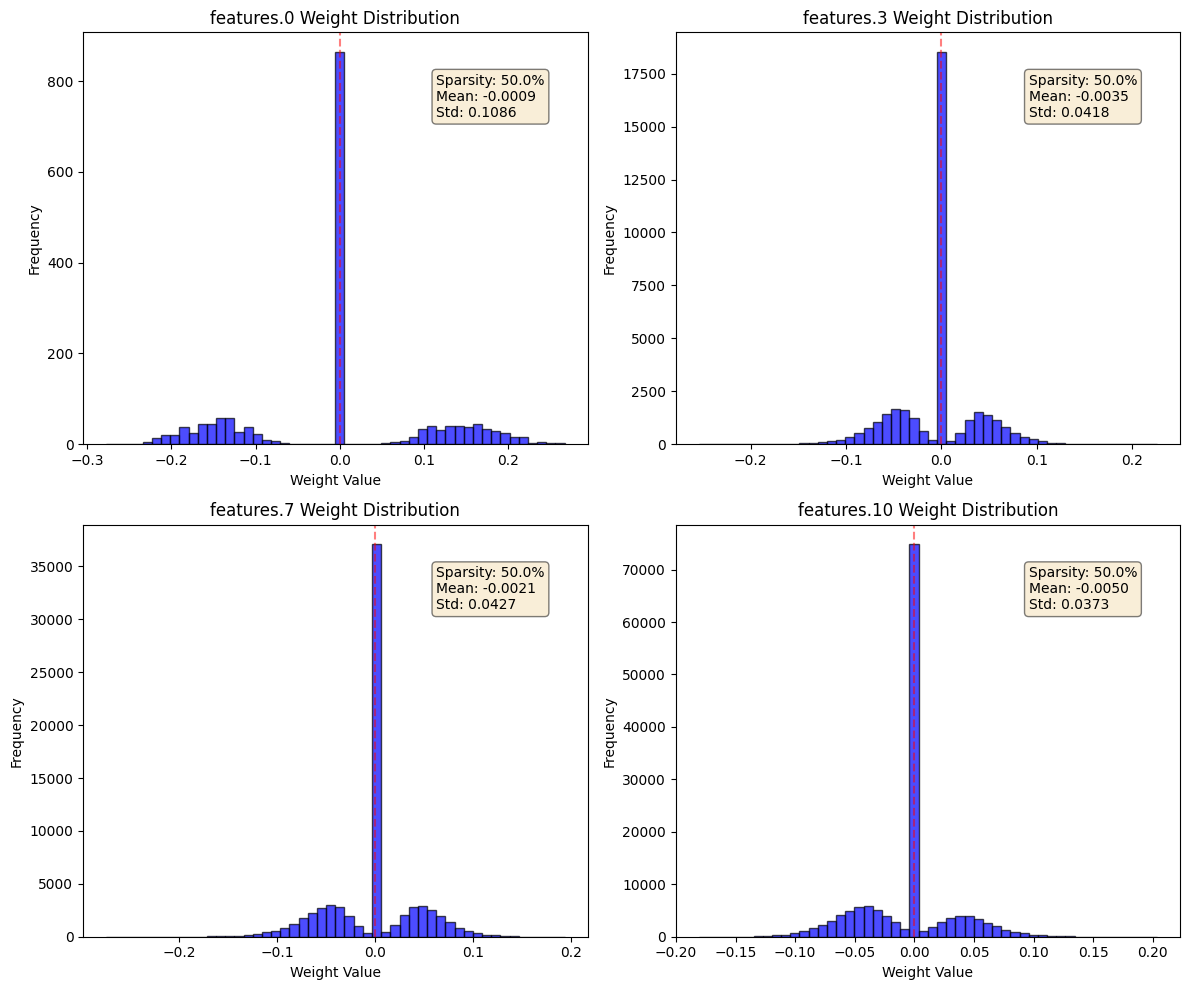


=== 반복적 프루닝 실험 ===

=== 반복 1/5, 목표 희소성: 0.0% ===
실제 희소성: 0.00%, 정확도: 77.77%

=== 반복 2/5, 목표 희소성: 20.0% ===

크기 기반 프루닝 적용 중... (pruning rate: 0.2)
Fine-tuning...
[Epoch 1, Batch 100] Loss: 0.788, Acc: 72.91%
[Epoch 1, Batch 200] Loss: 0.777, Acc: 73.04%
[Epoch 1, Batch 300] Loss: 0.800, Acc: 73.07%
[Epoch 2, Batch 100] Loss: 0.681, Acc: 76.59%
[Epoch 2, Batch 200] Loss: 0.675, Acc: 76.96%
[Epoch 2, Batch 300] Loss: 0.687, Acc: 76.91%
[Epoch 3, Batch 100] Loss: 0.586, Acc: 79.98%
[Epoch 3, Batch 200] Loss: 0.547, Acc: 80.77%
[Epoch 3, Batch 300] Loss: 0.568, Acc: 80.53%
실제 희소성: 20.00%, 정확도: 80.32%

=== 반복 3/5, 목표 희소성: 40.0% ===

크기 기반 프루닝 적용 중... (pruning rate: 0.25)
Fine-tuning...
[Epoch 1, Batch 100] Loss: 0.632, Acc: 78.59%
[Epoch 1, Batch 200] Loss: 0.629, Acc: 78.59%
[Epoch 1, Batch 300] Loss: 0.623, Acc: 78.58%
[Epoch 2, Batch 100] Loss: 0.557, Acc: 80.87%
[Epoch 2, Batch 200] Loss: 0.533, Acc: 81.25%
[Epoch 2, Batch 300] Loss: 0.545, Acc: 81.27%
[Epoch 3, Batch 100] Loss: 0.460, 

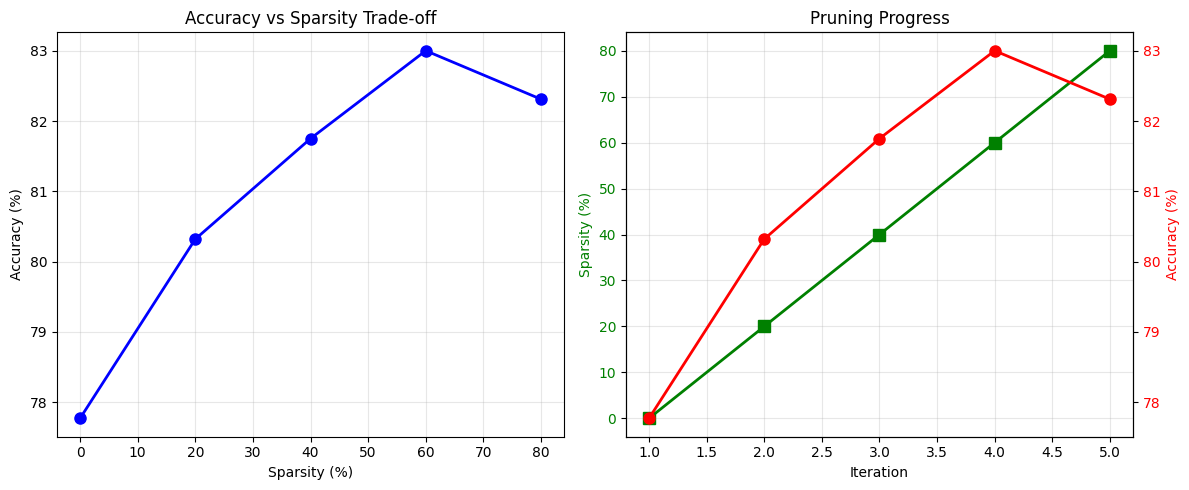


=== Lottery Ticket Hypothesis 실험 ===

=== Lottery Ticket 반복 1/3 ===
모델 학습 중...
[Epoch 1, Batch 100] Loss: 0.829, Acc: 71.45%
[Epoch 1, Batch 200] Loss: 0.815, Acc: 71.59%
[Epoch 1, Batch 300] Loss: 0.810, Acc: 72.04%
[Epoch 2, Batch 100] Loss: 0.724, Acc: 75.05%
[Epoch 2, Batch 200] Loss: 0.681, Acc: 75.84%
[Epoch 2, Batch 300] Loss: 0.695, Acc: 76.02%
[Epoch 3, Batch 100] Loss: 0.574, Acc: 80.23%
[Epoch 3, Batch 200] Loss: 0.566, Acc: 80.30%
[Epoch 3, Batch 300] Loss: 0.552, Acc: 80.53%
재학습 중...
[Epoch 1, Batch 100] Loss: 0.822, Acc: 71.79%
[Epoch 1, Batch 200] Loss: 0.794, Acc: 72.53%
[Epoch 1, Batch 300] Loss: 0.802, Acc: 72.67%
[Epoch 2, Batch 100] Loss: 0.721, Acc: 75.34%
[Epoch 2, Batch 200] Loss: 0.693, Acc: 75.84%
[Epoch 2, Batch 300] Loss: 0.679, Acc: 76.21%
[Epoch 3, Batch 100] Loss: 0.591, Acc: 79.55%
[Epoch 3, Batch 200] Loss: 0.541, Acc: 80.66%
[Epoch 3, Batch 300] Loss: 0.549, Acc: 80.76%
희소성: 26.13%, 정확도: 80.46%

=== Lottery Ticket 반복 2/3 ===
모델 학습 중...
[Epoch 1, Batch 

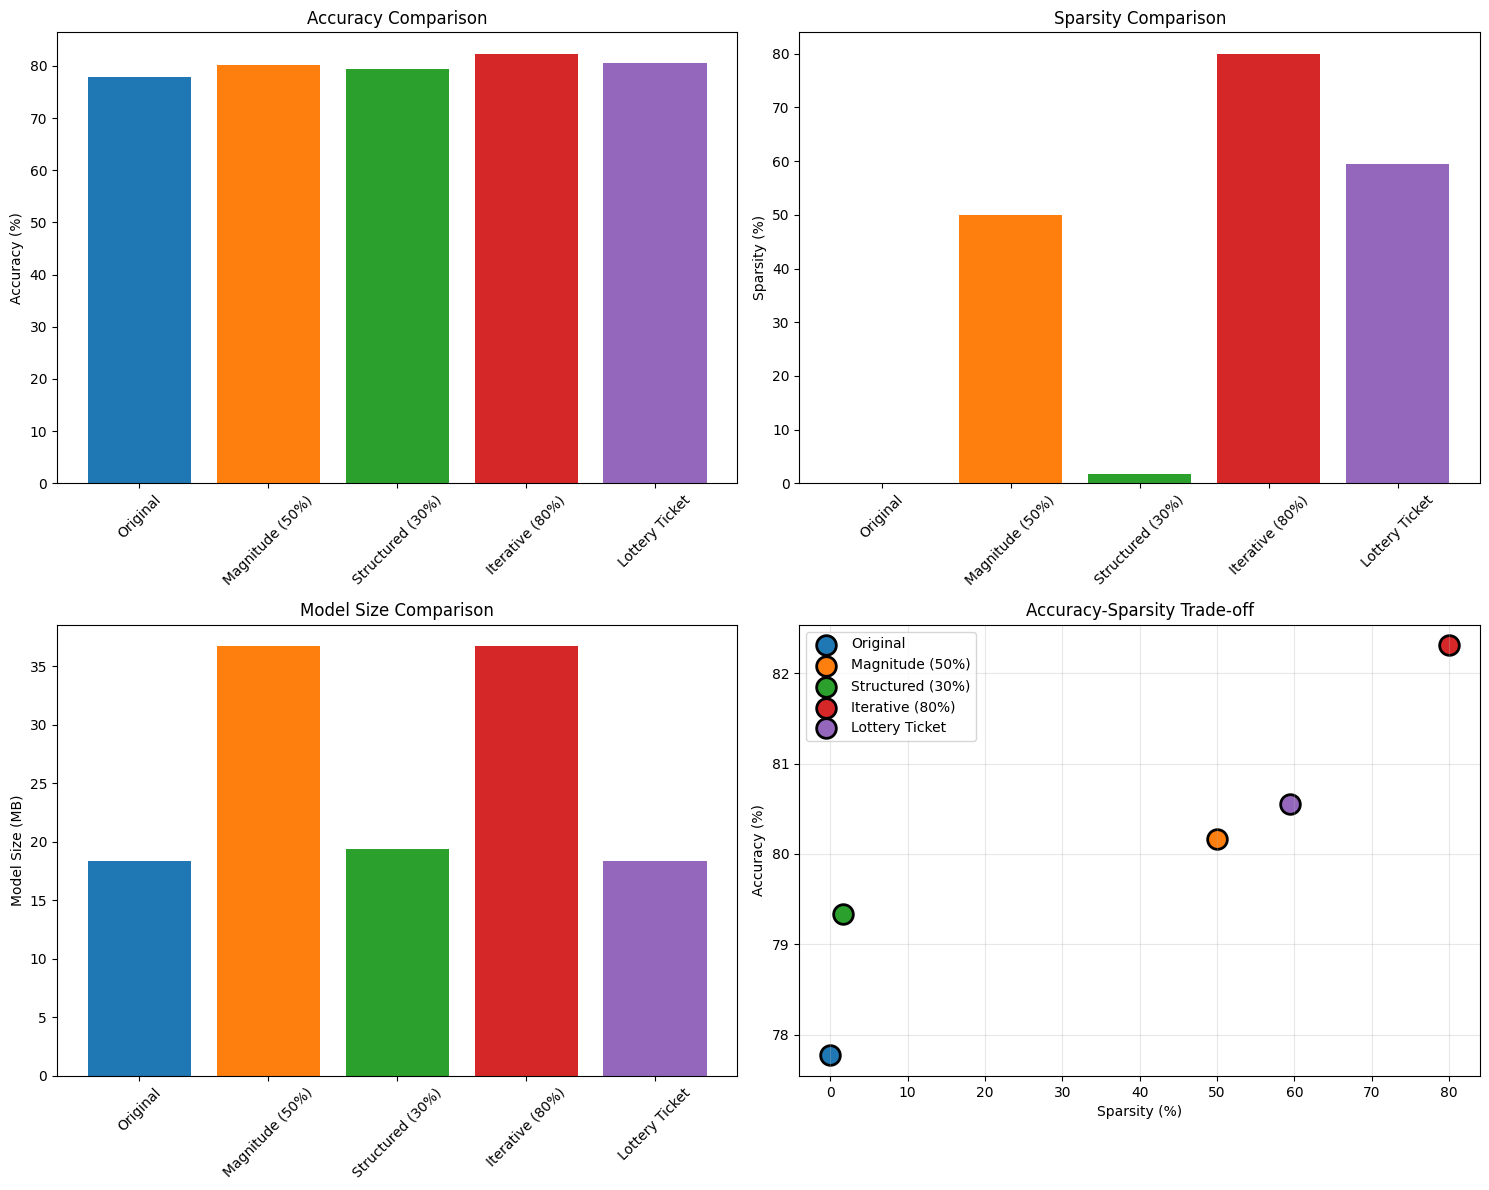


프루닝된 모델을 저장하시겠습니까? (y/n): ㅜ


In [11]:
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from collections import OrderedDict
import copy
import time
import os

# 랜덤 시드 고정
torch.manual_seed(42)
np.random.seed(42)

# GPU 사용 가능 여부 확인
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ===== 1. 모델 정의 =====
class PrunableCNN(nn.Module):
    """프루닝 실습을 위한 CNN 모델"""
    def __init__(self, num_classes=10):
        super(PrunableCNN, self).__init__()

        # Convolutional layers
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        # Fully connected layers
        self.classifier = nn.Sequential(
            nn.Linear(128 * 8 * 8, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

# ===== 2. 데이터 로딩 함수 =====
def load_cifar10(batch_size=128):
    """CIFAR-10 데이터셋 로드"""
    print("Loading CIFAR-10 dataset...")

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
    ])

    trainset = torchvision.datasets.CIFAR10(
        root='./data', train=True, download=True, transform=transform
    )
    trainloader = torch.utils.data.DataLoader(
        trainset, batch_size=batch_size, shuffle=True, num_workers=2
    )

    testset = torchvision.datasets.CIFAR10(
        root='./data', train=False, download=True, transform=transform
    )
    testloader = torch.utils.data.DataLoader(
        testset, batch_size=batch_size, shuffle=False, num_workers=2
    )

    return trainloader, testloader

# ===== 3. 프루닝 유틸리티 함수 =====
def calculate_sparsity(model):
    """모델의 희소성 계산"""
    zeros = 0
    total = 0

    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            if hasattr(module, 'weight_mask'):
                zeros += (module.weight_mask == 0).sum().item()
                total += module.weight_mask.numel()
            else:
                zeros += (module.weight == 0).sum().item()
                total += module.weight.numel()

    sparsity = zeros / total if total > 0 else 0
    return sparsity * 100

def count_parameters(model):
    """모델의 파라미터 수 계산"""
    total_params = 0
    nonzero_params = 0

    for param in model.parameters():
        total_params += param.numel()
        nonzero_params += (param != 0).sum().item()

    return total_params, nonzero_params

def print_model_size(model):
    """모델 크기 정보 출력"""
    total, nonzero = count_parameters(model)
    sparsity = calculate_sparsity(model)

    print(f"총 파라미터: {total:,}")
    print(f"0이 아닌 파라미터: {nonzero:,}")
    print(f"희소성: {sparsity:.2f}%")
    if nonzero > 0:
        print(f"압축률: {total/nonzero:.2f}x")

def get_model_size(model):
    """모델 크기 측정 (MB)"""
    torch.save(model.state_dict(), "temp_model.pth")
    size_mb = os.path.getsize("temp_model.pth") / 1e6
    os.remove("temp_model.pth")
    return size_mb

def measure_inference_time(model, input_shape=(1, 3, 32, 32), num_runs=100):
    """추론 시간 측정"""
    model.eval()
    device = next(model.parameters()).device
    dummy_input = torch.randn(input_shape).to(device)

    # Warm-up
    for _ in range(10):
        with torch.no_grad():
            _ = model(dummy_input)

    # 실제 측정
    torch.cuda.synchronize() if device.type == 'cuda' else None
    start_time = time.time()

    for _ in range(num_runs):
        with torch.no_grad():
            _ = model(dummy_input)

    torch.cuda.synchronize() if device.type == 'cuda' else None
    end_time = time.time()

    avg_time = (end_time - start_time) / num_runs * 1000  # ms
    return avg_time

# ===== 4. 학습 및 평가 함수 =====
def train_model(model, train_loader, epochs=10, device='cpu', lr=0.001):
    """모델 학습"""
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        for i, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            if i % 100 == 99:
                print(f'[Epoch {epoch + 1}, Batch {i + 1}] Loss: {running_loss / 100:.3f}, '
                      f'Acc: {100 * correct / total:.2f}%')
                running_loss = 0.0

        scheduler.step()

    return model

def evaluate_model(model, test_loader, device='cpu'):
    """모델 평가"""
    model = model.to(device)
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    return accuracy

# ===== 5. 기본 프루닝 함수 =====
def magnitude_pruning(model, pruning_rate=0.2):
    """크기 기반 비구조적 프루닝"""
    print(f"\n크기 기반 프루닝 적용 중... (pruning rate: {pruning_rate})")

    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            prune.l1_unstructured(module, name='weight', amount=pruning_rate)
        elif isinstance(module, nn.Linear):
            prune.l1_unstructured(module, name='weight', amount=pruning_rate)

    return model

def structured_pruning(model, pruning_rate=0.2):
    """구조적 프루닝 - 채널 단위"""
    print(f"\n구조적 프루닝 적용 중... (pruning rate: {pruning_rate})")

    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            prune.ln_structured(module, name='weight', amount=pruning_rate,
                              n=2, dim=0)  # dim=0은 출력 채널

    return model

def remove_pruning(model):
    """프루닝 마스크를 영구적으로 적용"""
    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            if hasattr(module, 'weight_mask'):
                prune.remove(module, 'weight')
    return model

# ===== 6. 반복적 프루닝 =====
def iterative_pruning(model, train_loader, test_loader, target_sparsity=0.9,
                     num_iterations=10, device='cpu'):
    """반복적 프루닝 with fine-tuning"""

    model = model.to(device)

    # 프루닝 스케줄 생성
    sparsities = np.linspace(0, target_sparsity, num_iterations)

    results = []

    for i, sparsity in enumerate(sparsities):
        print(f"\n=== 반복 {i+1}/{num_iterations}, 목표 희소성: {sparsity*100:.1f}% ===")

        # 프루닝 적용
        if i > 0:
            pruning_rate = (sparsity - sparsities[i-1]) / (1 - sparsities[i-1])
            model = magnitude_pruning(model, pruning_rate)

        # Fine-tuning
        if i > 0:  # 첫 반복은 스킵
            print("Fine-tuning...")
            model = train_model(model, train_loader, epochs=3, device=device)

        # 평가
        accuracy = evaluate_model(model, test_loader, device)
        current_sparsity = calculate_sparsity(model)

        results.append({
            'iteration': i+1,
            'target_sparsity': sparsity * 100,
            'actual_sparsity': current_sparsity,
            'accuracy': accuracy
        })

        print(f"실제 희소성: {current_sparsity:.2f}%, 정확도: {accuracy:.2f}%")

    return model, results

# ===== 7. Lottery Ticket Hypothesis =====
class LotteryTicketPruning:
    """Lottery Ticket Hypothesis 구현"""

    def __init__(self, model, pruning_rate=0.2):
        self.original_model = copy.deepcopy(model)
        self.pruning_rate = pruning_rate
        self.initial_state = None
        self.masks = {}

    def save_initial_weights(self):
        """초기 가중치 저장"""
        self.initial_state = copy.deepcopy(self.original_model.state_dict())

    def create_mask(self, model):
        """현재 모델 기반으로 마스크 생성"""
        self.masks = {}

        for name, module in model.named_modules():
            if isinstance(module, (nn.Conv2d, nn.Linear)):
                weight = module.weight.data.abs()
                threshold = torch.quantile(weight.flatten(), self.pruning_rate)
                mask = weight > threshold
                self.masks[name + '.weight'] = mask

    def apply_mask(self, model):
        """마스크를 모델에 적용"""
        for name, module in model.named_modules():
            if isinstance(module, (nn.Conv2d, nn.Linear)):
                key = name + '.weight'
                if key in self.masks:
                    module.weight.data *= self.masks[key]

    def find_winning_ticket(self, train_loader, test_loader, iterations=3,
                          epochs_per_iteration=5, device='cpu'):
        """우승 복권 찾기"""

        self.save_initial_weights()
        results = []

        for iteration in range(iterations):
            print(f"\n=== Lottery Ticket 반복 {iteration+1}/{iterations} ===")

            # 모델 초기화
            model = copy.deepcopy(self.original_model)
            model.load_state_dict(self.initial_state)
            model = model.to(device)

            # 이전 마스크가 있으면 적용
            if self.masks:
                self.apply_mask(model)

            # 학습
            print("모델 학습 중...")
            model = train_model(model, train_loader, epochs=epochs_per_iteration, device=device)

            # 새로운 마스크 생성
            self.create_mask(model)

            # 초기 가중치로 되돌리고 마스크 적용
            model.load_state_dict(self.initial_state)
            self.apply_mask(model)

            # 재학습
            print("재학습 중...")
            model = train_model(model, train_loader, epochs=epochs_per_iteration, device=device)

            # 평가
            accuracy = evaluate_model(model, test_loader, device)
            sparsity = calculate_sparsity(model)

            results.append({
                'iteration': iteration + 1,
                'sparsity': sparsity,
                'accuracy': accuracy
            })

            print(f"희소성: {sparsity:.2f}%, 정확도: {accuracy:.2f}%")

            # 다음 반복을 위해 pruning rate 증가
            self.pruning_rate = min(self.pruning_rate + 0.2, 0.9)

        return model, results

# ===== 8. 시각화 함수 =====
def visualize_weight_distribution(model, save_path='weight_distribution.png'):
    """가중치 분포 시각화"""
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.ravel()

    layer_idx = 0
    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            if layer_idx >= 4:
                break

            weights = module.weight.data.cpu().numpy().flatten()

            # 히스토그램
            axes[layer_idx].hist(weights, bins=50, alpha=0.7, color='blue', edgecolor='black')
            axes[layer_idx].axvline(x=0, color='red', linestyle='--', alpha=0.5)
            axes[layer_idx].set_title(f'{name} Weight Distribution')
            axes[layer_idx].set_xlabel('Weight Value')
            axes[layer_idx].set_ylabel('Frequency')

            # 통계 정보
            zeros = (weights == 0).sum()
            total = len(weights)
            sparsity = zeros / total * 100

            stats_text = f'Sparsity: {sparsity:.1f}%\nMean: {weights.mean():.4f}\nStd: {weights.std():.4f}'
            axes[layer_idx].text(0.7, 0.9, stats_text, transform=axes[layer_idx].transAxes,
                                verticalalignment='top',
                                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

            layer_idx += 1

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

def plot_pruning_results(results, save_path='pruning_results.png'):
    """프루닝 결과 시각화"""
    df = pd.DataFrame(results)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # 희소성 vs 정확도
    ax1.plot(df['actual_sparsity'], df['accuracy'], 'b-o', linewidth=2, markersize=8)
    ax1.set_xlabel('Sparsity (%)')
    ax1.set_ylabel('Accuracy (%)')
    ax1.set_title('Accuracy vs Sparsity Trade-off')
    ax1.grid(True, alpha=0.3)

    # 반복 횟수에 따른 변화
    ax2.plot(df['iteration'], df['actual_sparsity'], 'g-s', label='Sparsity', linewidth=2, markersize=8)
    ax2.set_xlabel('Iteration')
    ax2.set_ylabel('Sparsity (%)', color='g')
    ax2.tick_params(axis='y', labelcolor='g')

    ax2_twin = ax2.twinx()
    ax2_twin.plot(df['iteration'], df['accuracy'], 'r-o', label='Accuracy', linewidth=2, markersize=8)
    ax2_twin.set_ylabel('Accuracy (%)', color='r')
    ax2_twin.tick_params(axis='y', labelcolor='r')

    ax2.set_title('Pruning Progress')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

def compare_pruning_methods(results_dict, save_path='pruning_comparison.png'):
    """여러 프루닝 방법 비교"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    methods = list(results_dict.keys())
    colors = plt.cm.tab10(np.arange(len(methods)))

    # 1. 정확도 비교
    accuracies = [results_dict[m]['accuracy'] for m in methods]
    axes[0, 0].bar(methods, accuracies, color=colors)
    axes[0, 0].set_ylabel('Accuracy (%)')
    axes[0, 0].set_title('Accuracy Comparison')
    axes[0, 0].tick_params(axis='x', rotation=45)

    # 2. 희소성 비교
    sparsities = [results_dict[m]['sparsity'] for m in methods]
    axes[0, 1].bar(methods, sparsities, color=colors)
    axes[0, 1].set_ylabel('Sparsity (%)')
    axes[0, 1].set_title('Sparsity Comparison')
    axes[0, 1].tick_params(axis='x', rotation=45)

    # 3. 모델 크기 비교
    sizes = [results_dict[m]['size'] for m in methods]
    axes[1, 0].bar(methods, sizes, color=colors)
    axes[1, 0].set_ylabel('Model Size (MB)')
    axes[1, 0].set_title('Model Size Comparison')
    axes[1, 0].tick_params(axis='x', rotation=45)

    # 4. Trade-off 산점도
    for i, method in enumerate(methods):
        axes[1, 1].scatter(sparsities[i], accuracies[i], s=200, c=[colors[i]],
                          label=method, edgecolors='black', linewidth=2)

    axes[1, 1].set_xlabel('Sparsity (%)')
    axes[1, 1].set_ylabel('Accuracy (%)')
    axes[1, 1].set_title('Accuracy-Sparsity Trade-off')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# ===== 9. 메인 실행 함수 =====
def main():
    """메인 실행 함수"""
    print("=== 모델 프루닝 실습 시작 ===\n")

    # 데이터 로드
    train_loader, test_loader = load_cifar10(batch_size=128)

    # 실험 선택
    print("\n실행할 실험을 선택하세요:")
    print("1. 기본 프루닝 비교 (빠름)")
    print("2. 반복적 프루닝 (중간)")
    print("3. Lottery Ticket Hypothesis (느림)")
    print("4. 전체 실험 (매우 느림)")

    choice = input("\n선택 (1-4): ") or "1"

    # 모델 생성
    print("\n모델 생성 중...")
    model = PrunableCNN()

    # 사전 학습된 모델 사용 여부
    use_pretrained = input("사전 학습된 모델을 사용하시겠습니까? (y/n, 기본값: n): ").lower() == 'y'

    if use_pretrained:
        print("MobileNetV2 사전 학습 모델 로드 중...")
        model = torchvision.models.mobilenet_v2(pretrained=True)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, 10)
    else:
        print("새 모델 학습 중... (시간이 걸릴 수 있습니다)")
        model = train_model(model, train_loader, epochs=5, device=device)

    # 원본 모델 평가
    print("\n=== 원본 모델 평가 ===")
    original_acc = evaluate_model(model, test_loader, device)
    original_size = get_model_size(model)
    original_time = measure_inference_time(model.to(device))

    print(f"정확도: {original_acc:.2f}%")
    print(f"모델 크기: {original_size:.2f} MB")
    print(f"추론 시간: {original_time:.2f} ms")
    print_model_size(model)

    results_dict = {
        'Original': {
            'accuracy': original_acc,
            'sparsity': 0,
            'size': original_size,
            'time': original_time
        }
    }

    if choice in ['1', '4']:
        # 기본 프루닝 비교
        print("\n=== 기본 프루닝 실험 ===")

        # 1. Magnitude Pruning
        print("\n--- Magnitude Pruning (50%) ---")
        mag_model = copy.deepcopy(model)
        mag_model = magnitude_pruning(mag_model, pruning_rate=0.5)

        # Fine-tuning
        if not use_pretrained:
            print("Fine-tuning...")
            mag_model = train_model(mag_model, train_loader, epochs=3, device=device)

        mag_acc = evaluate_model(mag_model, test_loader, device)
        mag_sparsity = calculate_sparsity(mag_model)
        mag_size = get_model_size(mag_model)

        results_dict['Magnitude (50%)'] = {
            'accuracy': mag_acc,
            'sparsity': mag_sparsity,
            'size': mag_size,
            'time': measure_inference_time(mag_model.to(device))
        }

        print(f"\n결과: 정확도={mag_acc:.2f}%, 희소성={mag_sparsity:.2f}%")

        # 2. Structured Pruning
        print("\n--- Structured Pruning (30%) ---")
        struct_model = copy.deepcopy(model)
        struct_model = structured_pruning(struct_model, pruning_rate=0.3)

        if not use_pretrained:
            print("Fine-tuning...")
            struct_model = train_model(struct_model, train_loader, epochs=3, device=device)

        struct_acc = evaluate_model(struct_model, test_loader, device)
        struct_sparsity = calculate_sparsity(struct_model)
        struct_size = get_model_size(struct_model)

        results_dict['Structured (30%)'] = {
            'accuracy': struct_acc,
            'sparsity': struct_sparsity,
            'size': struct_size,
            'time': measure_inference_time(struct_model.to(device))
        }

        print(f"\n결과: 정확도={struct_acc:.2f}%, 희소성={struct_sparsity:.2f}%")

        # 가중치 분포 시각화
        print("\n가중치 분포 시각화 중...")
        visualize_weight_distribution(mag_model)

    if choice in ['2', '4']:
        # 반복적 프루닝
        print("\n=== 반복적 프루닝 실험 ===")
        iter_model = copy.deepcopy(model)
        iter_model, iter_results = iterative_pruning(
            iter_model, train_loader, test_loader,
            target_sparsity=0.8, num_iterations=5, device=device
        )

        # 결과 시각화
        plot_pruning_results(iter_results)

        # 최종 결과 저장
        final_result = iter_results[-1]
        results_dict['Iterative (80%)'] = {
            'accuracy': final_result['accuracy'],
            'sparsity': final_result['actual_sparsity'],
            'size': get_model_size(iter_model),
            'time': measure_inference_time(iter_model)
        }

    if choice in ['3', '4']:
        # Lottery Ticket Hypothesis
        print("\n=== Lottery Ticket Hypothesis 실험 ===")
        lottery = LotteryTicketPruning(model, pruning_rate=0.3)
        lottery_model, lottery_results = lottery.find_winning_ticket(
            train_loader, test_loader, iterations=3,
            epochs_per_iteration=3, device=device
        )

        # 최종 결과 저장
        final_lottery = lottery_results[-1]
        results_dict['Lottery Ticket'] = {
            'accuracy': final_lottery['accuracy'],
            'sparsity': final_lottery['sparsity'],
            'size': get_model_size(lottery_model),
            'time': measure_inference_time(lottery_model)
        }

    # 전체 결과 비교
    print("\n=== 전체 결과 요약 ===")
    for method, metrics in results_dict.items():
        print(f"\n{method}:")
        print(f"  - 정확도: {metrics['accuracy']:.2f}%")
        print(f"  - 희소성: {metrics['sparsity']:.2f}%")
        print(f"  - 모델 크기: {metrics['size']:.2f} MB")
        print(f"  - 추론 시간: {metrics['time']:.2f} ms")

    # 비교 시각화
    if len(results_dict) > 1:
        print("\n결과 시각화 중...")
        compare_pruning_methods(results_dict)

    # 모델 저장 여부
    save_models = input("\n프루닝된 모델을 저장하시겠습니까? (y/n): ").lower() == 'y'
    if save_models:
        for method, model_to_save in [('magnitude', mag_model), ('structured', struct_model)]:
            if method in locals():
                torch.save(model_to_save.state_dict(), f'{method}_pruned_model.pth')
                print(f"{method} 프루닝 모델이 저장되었습니다.")

if __name__ == "__main__":
    main()

## 6. 고급 프루닝 기법

### 6.1 그래디언트 기반 프루닝

In [12]:
class GradientBasedPruning:
    """그래디언트 정보를 활용한 프루닝"""

    def __init__(self, model):
        self.model = model
        self.gradients = {}
        self.register_hooks()

    def register_hooks(self):
        """그래디언트 수집을 위한 hook 등록"""
        for name, module in self.model.named_modules():
            if isinstance(module, (nn.Conv2d, nn.Linear)):
                module.register_backward_hook(self.save_gradient(name))

    def save_gradient(self, name):
        def hook(module, grad_input, grad_output):
            if hasattr(module, 'weight'):
                grad = module.weight.grad
                if grad is not None:
                    if name not in self.gradients:
                        self.gradients[name] = []
                    self.gradients[name].append(grad.abs().clone())
        return hook

    def compute_importance(self):
        """평균 그래디언트 기반 중요도 계산"""
        importance_scores = {}

        for name, grad_list in self.gradients.items():
            if grad_list:
                # 평균 그래디언트 계산
                avg_grad = torch.stack(grad_list).mean(dim=0)
                importance_scores[name] = avg_grad

        return importance_scores

    def prune_by_gradient(self, pruning_rate=0.2):
        """그래디언트 기반 프루닝 적용"""
        importance_scores = self.compute_importance()

        for name, module in self.model.named_modules():
            if isinstance(module, (nn.Conv2d, nn.Linear)) and name in importance_scores:
                importance = importance_scores[name]
                threshold = torch.quantile(importance.flatten(), pruning_rate)
                mask = importance > threshold

                # 마스크 적용
                with torch.no_grad():
                    module.weight.data *= mask

### 6.2 Taylor Expansion 기반 프루닝

In [13]:
def taylor_pruning(model, data_loader, pruning_rate=0.2):
    """Taylor expansion을 이용한 중요도 계산"""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()

    # 그래디언트와 활성화 저장
    gradients = {}
    activations = {}

    def forward_hook(name):
        def hook(module, input, output):
            activations[name] = output.detach()
        return hook

    def backward_hook(name):
        def hook(module, grad_input, grad_output):
            gradients[name] = grad_output[0].detach()
        return hook

    # Hook 등록
    handles = []
    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            handles.append(module.register_forward_hook(forward_hook(name)))
            handles.append(module.register_backward_hook(backward_hook(name)))

    # 데이터 통과
    criterion = nn.CrossEntropyLoss()
    for inputs, targets in data_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        break  # 한 배치만 사용

    # Hook 제거
    for handle in handles:
        handle.remove()

    # Taylor importance 계산 및 프루닝
    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)) and name in activations:
            # Importance = |gradient * activation|
            importance = (gradients[name] * activations[name]).abs().mean(dim=0)

            if len(importance.shape) > 1:  # Conv2d
                importance = importance.mean(dim=(1, 2))  # 채널별 평균

            # 프루닝 적용
            num_channels = importance.shape[0]
            num_prune = int(num_channels * pruning_rate)
            _, indices = torch.topk(importance, num_prune, largest=False)

            # 마스크 생성
            mask = torch.ones_like(module.weight.data)
            mask[indices] = 0

            # 적용
            prune.custom_from_mask(module, name='weight', mask=mask)

    return model

### 6.3 동적 희소 학습 (Dynamic Sparse Training)

In [14]:
class DynamicSparseTraining:
    """학습 중 동적으로 연결을 추가/제거"""

    def __init__(self, model, sparsity=0.9, update_frequency=100):
        self.model = model
        self.sparsity = sparsity
        self.update_frequency = update_frequency
        self.step = 0
        self.masks = self.create_initial_masks()

    def create_initial_masks(self):
        """초기 마스크 생성 (랜덤)"""
        masks = {}

        for name, module in self.model.named_modules():
            if isinstance(module, (nn.Conv2d, nn.Linear)):
                # 랜덤 마스크 생성
                shape = module.weight.shape
                mask = torch.rand(shape) > self.sparsity
                masks[name] = mask.to(module.weight.device)

                # 마스크 적용
                module.weight.data *= masks[name]

        return masks

    def update_connections(self):
        """Grow and prune connections"""
        for name, module in self.model.named_modules():
            if isinstance(module, (nn.Conv2d, nn.Linear)) and name in self.masks:
                # 현재 가중치
                weights = module.weight.data
                mask = self.masks[name]

                # Prune: 작은 가중치 제거
                alive_weights = weights[mask.bool()]
                percentile = 20  # 하위 20% 제거
                threshold = torch.quantile(alive_weights.abs(), percentile/100)
                new_mask = (weights.abs() > threshold) & mask.bool()

                # Grow: 그래디언트가 큰 위치에 연결 추가
                num_removed = mask.sum() - new_mask.sum()
                if num_removed > 0 and hasattr(module.weight, 'grad') and module.weight.grad is not None:
                    grad_magnitude = module.weight.grad.abs()
                    grad_magnitude[mask.bool()] = 0  # 이미 연결된 부분 제외

                    # Top-k 그래디언트 위치 찾기
                    _, indices = torch.topk(grad_magnitude.flatten(), num_removed.item())
                    new_connections = torch.zeros_like(mask.flatten())
                    new_connections[indices] = 1
                    new_connections = new_connections.reshape(mask.shape)

                    new_mask = new_mask | new_connections.bool()

                # 마스크 업데이트
                self.masks[name] = new_mask.float()
                module.weight.data *= self.masks[name]

    def step_update(self):
        """학습 스텝마다 호출"""
        self.step += 1
        if self.step % self.update_frequency == 0:
            self.update_connections()

## 7. 성능 비교 및 분석

### 전체 프루닝 비교 실험

In [15]:
def comprehensive_pruning_comparison(model, train_loader, test_loader):
    """다양한 프루닝 기법 비교"""

    results = {
        'method': [],
        'sparsity': [],
        'accuracy': [],
        'inference_time': [],
        'model_size': []
    }

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # 1. 원본 모델
    original_model = copy.deepcopy(model).to(device)
    original_acc = evaluate_model(original_model, test_loader, device)
    original_time = measure_inference_time(original_model)
    original_size = get_model_size(original_model)

    results['method'].append('Original')
    results['sparsity'].append(0)
    results['accuracy'].append(original_acc)
    results['inference_time'].append(original_time)
    results['model_size'].append(original_size)

    # 2. Magnitude Pruning
    mag_model = copy.deepcopy(model).to(device)
    mag_model = magnitude_pruning(mag_model, pruning_rate=0.5)
    mag_model = train_model(mag_model, train_loader, epochs=5, device=device)

    results['method'].append('Magnitude (50%)')
    results['sparsity'].append(calculate_sparsity(mag_model))
    results['accuracy'].append(evaluate_model(mag_model, test_loader, device))
    results['inference_time'].append(measure_inference_time(mag_model))
    results['model_size'].append(get_model_size(mag_model))

    # 3. Structured Pruning
    struct_model = copy.deepcopy(model).to(device)
    struct_model = structured_pruning(struct_model, pruning_rate=0.3)
    struct_model = train_model(struct_model, train_loader, epochs=5, device=device)

    results['method'].append('Structured (30%)')
    results['sparsity'].append(calculate_sparsity(struct_model))
    results['accuracy'].append(evaluate_model(struct_model, test_loader, device))
    results['inference_time'].append(measure_inference_time(struct_model))
    results['model_size'].append(get_model_size(struct_model))

    # 4. Iterative Pruning
    iter_model = copy.deepcopy(model)
    iter_model, iter_results = iterative_pruning(
        iter_model, train_loader, test_loader,
        target_sparsity=0.8, num_iterations=5
    )

    results['method'].append('Iterative (80%)')
    results['sparsity'].append(calculate_sparsity(iter_model))
    results['accuracy'].append(iter_results[-1]['accuracy'])
    results['inference_time'].append(measure_inference_time(iter_model))
    results['model_size'].append(get_model_size(iter_model))

    # 결과 DataFrame 생성
    df_results = pd.DataFrame(results)

    # 시각화
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # 1. 방법별 비교
    x = np.arange(len(df_results))
    width = 0.35

    axes[0, 0].bar(x - width/2, df_results['accuracy'], width, label='Accuracy (%)', color='blue')
    axes[0, 0].bar(x + width/2, df_results['sparsity'], width, label='Sparsity (%)', color='orange')
    axes[0, 0].set_xlabel('Pruning Method')
    axes[0, 0].set_ylabel('Percentage')
    axes[0, 0].set_title('Accuracy vs Sparsity by Method')
    axes[0, 0].set_xticks(x)
    axes[0, 0].set_xticklabels(df_results['method'], rotation=45)
    axes[0, 0].legend()

    # 2. 추론 시간
    axes[0, 1].bar(df_results['method'], df_results['inference_time'], color='green')
    axes[0, 1].set_xlabel('Pruning Method')
    axes[0, 1].set_ylabel('Inference Time (ms)')
    axes[0, 1].set_title('Inference Time Comparison')
    axes[0, 1].tick_params(axis='x', rotation=45)

    # 3. 모델 크기
    axes[1, 0].bar(df_results['method'], df_results['model_size'], color='red')
    axes[1, 0].set_xlabel('Pruning Method')
    axes[1, 0].set_ylabel('Model Size (MB)')
    axes[1, 0].set_title('Model Size Comparison')
    axes[1, 0].tick_params(axis='x', rotation=45)

    # 4. Trade-off 분석
    axes[1, 1].scatter(df_results['sparsity'], df_results['accuracy'], s=200, c=range(len(df_results)), cmap='viridis')
    for i, method in enumerate(df_results['method']):
        axes[1, 1].annotate(method, (df_results['sparsity'][i], df_results['accuracy'][i]),
                           xytext=(5, 5), textcoords='offset points', fontsize=10)
    axes[1, 1].set_xlabel('Sparsity (%)')
    axes[1, 1].set_ylabel('Accuracy (%)')
    axes[1, 1].set_title('Accuracy-Sparsity Trade-off')
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('pruning_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

    return df_results

## 8. Best Practices

### 8.1 프루닝 전략 선택

In [16]:
def select_pruning_strategy(model_type, hardware, requirements):
    """모델과 하드웨어에 따른 최적 프루닝 전략"""

    strategies = {
        'mobile': {
            'method': 'structured',
            'target_sparsity': 0.5,
            'reason': '모바일 하드웨어는 구조적 프루닝이 효과적'
        },
        'server_gpu': {
            'method': 'unstructured',
            'target_sparsity': 0.9,
            'reason': 'GPU는 희소 연산 지원으로 높은 희소성 가능'
        },
        'edge_device': {
            'method': 'mixed',
            'target_sparsity': 0.7,
            'reason': '엣지 디바이스는 균형잡힌 접근 필요'
        }
    }

    return strategies.get(hardware, strategies['mobile'])